In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# reading the dataset
words = open('names.txt', 'r').read().splitlines()
words[:5], len(words)

(['emma', 'olivia', 'ava', 'isabella', 'sophia'], 32033)

In [4]:
# building the vocabulary of characters and mappings
chars = sorted(set(''.join(words)))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}
vocab_size = len(itos) # since our vocabulary is just the characters

In [5]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
    return X, Y


import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((block_size * n_embd, 200),    generator=g)
b1 = torch.randn(n_hidden,                      generator=g)
W2 = torch.randn((n_hidden, vocab_size),        generator=g)
b2 = torch.randn(vocab_size,                    generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [6]:
sum(p.nelement() for p in parameters)

11897

In [7]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the two vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre activation
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weight updates
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    

      0/ 200000: 27.8817
  10000/ 200000: 2.8138
  20000/ 200000: 2.5218
  30000/ 200000: 2.7874
  40000/ 200000: 2.0334
  50000/ 200000: 2.6237
  60000/ 200000: 2.3289
  70000/ 200000: 2.0826
  80000/ 200000: 2.2784
  90000/ 200000: 2.2252
 100000/ 200000: 2.0428
 110000/ 200000: 2.3121
 120000/ 200000: 2.0570
 130000/ 200000: 2.4546
 140000/ 200000: 2.2233
 150000/ 200000: 2.1551
 160000/ 200000: 2.0597
 170000/ 200000: 1.7981
 180000/ 200000: 2.0194
 190000/ 200000: 1.7459


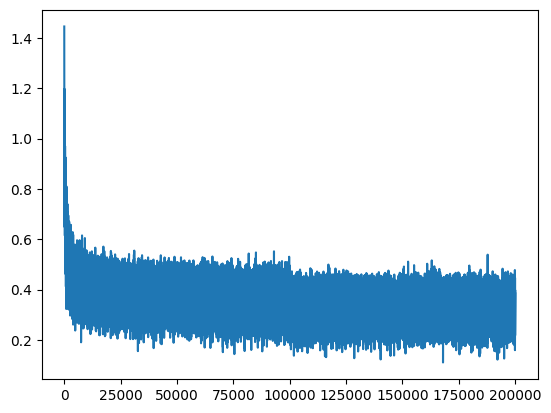

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 2.1267659664154053
val 2.1697638034820557


In [12]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(emb.shape[0], -1)
        h = torch.tanh(embcat @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, 1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    
    print(''.join(out))
        

carlah.
amorie.
khirmin.
rey.
cassanden.
jazhubedah.
sart.
kaeli.
nellara.
chaiir.


we can see that the loss in the first iteration is very high.\
reason for that is our neural network is not initialized correctly\
what should be our baseline model initialization? => every character is equally like to come next.\
so basically, probability of every character to come next should (1/27.0) in our case.\
So, our model should be initialized to kind of have this configurations.

In [ ]:
# so if probability of each character would be 1/27, we can find the loss for that
-torch.tensor(1/27.0).log()
# tensor(3.2958)

# so this is the base loss we can expect
# but how do we initialize in the network

tensor(3.2958)

In [ ]:
 # 4 dimensional example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4) * 100
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log() # considering the label is 2
logits, probs, loss

# in case of extreme values, loss would be too high. Randomly initializing weights has this problem
# so we want logits to be roughly zero or they should be equal so as we hit the base loss
# if numbers are equal, probs would still be the same, but we don't want to assign logits an arbitrary negative or positive value so just 0 is fine

(tensor([  4.1077,  67.5751,  11.2680, -56.3347]),
 tensor([2.7319e-28, 1.0000e+00, 3.5168e-25, 0.0000e+00]),
 tensor(56.3071))

In [ ]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((block_size * n_embd, 200),    generator=g) * (5/3)/((block_size * n_embd) ** 0.5)  #  <=this is Kaiming init #* 0.2
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0 # initialization to make logits zero
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [56]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the two vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre activation
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weight updates
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    

      0/ 200000: 3.3135
  10000/ 200000: 2.1648
  20000/ 200000: 2.3061
  30000/ 200000: 2.4541
  40000/ 200000: 1.9787
  50000/ 200000: 2.2930
  60000/ 200000: 2.4232
  70000/ 200000: 2.0680
  80000/ 200000: 2.3095
  90000/ 200000: 2.1207
 100000/ 200000: 1.8269
 110000/ 200000: 2.2045
 120000/ 200000: 1.9797
 130000/ 200000: 2.3946
 140000/ 200000: 2.1000
 150000/ 200000: 2.1948
 160000/ 200000: 1.8619
 170000/ 200000: 1.7809
 180000/ 200000: 1.9673
 190000/ 200000: 1.8295


In [ ]:
# so the loss after the first iteration is very high
# if we look at the logits here
print(logits[0])
# tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
    #       1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
    #      -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
    #      14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
    #    grad_fn=<SelectBackward0>)
    
# after the initialization, checking the logits
# tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
#          0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
#         -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
#         -0.2154,  0.0725,  0.1141], grad_fn=<SelectBackward0>)

# logits are coming much more symmetrical and not taking extreme values

tensor([-0.0249,  0.3523, -0.1267,  0.0541,  0.1662, -0.1171, -0.0140,  0.0124,
         0.0921,  0.1135,  0.1362, -0.0925,  0.0444, -0.2459, -0.0971,  0.0125,
        -0.0957, -0.1376, -0.2329, -0.0137,  0.2452,  0.1616,  0.1665, -0.1094,
        -0.2154,  0.0725,  0.1141], grad_fn=<SelectBackward0>)


we see here that logits are taking very extreme values and hence the high loss\
so what can we do to make the logits roughly zero here\
since logits = h @ W2 + b2\
first thing that we can do is that we can make b2 zero at the initialization\
also we can make W2 zero too. But we won't do that as of now but we will make W2 a very small value\

so after the initialization, we can see that the initial loss is very low =>       0/ 200000: 3.3221
       

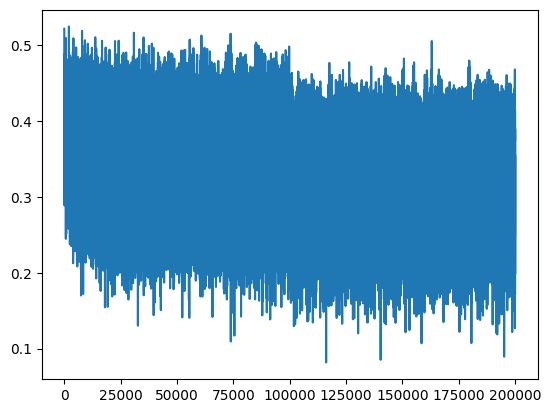

In [ ]:
plt.plot(lossi)

# we are not getting a hockey stick type of curve now as initialization is much better than before
# getting a good initialization matters as we are not wasting the first few iterations on just squashing down the weights
# we can start improving the neural network from the get go

In [ ]:
split_loss('train')
split_loss('val')

# after fixing the softmax
# train 2.0695888996124268
# val 2.131074905395508

# after fixing tanh saturation at init
# train 2.0355966091156006
# val 2.1026782989501953

# also train and val loss have also slightly improved

train 2.0355966091156006
val 2.1026782989501953


In [ ]:
print(h) # this is the h after just one iteration
# we can see that some of the values are taking 1 and -1. This is due to tanh squashing values between -1 and 1
# we can improve on this by checking the distribution of h
print(h.shape) # torch.Size([32, 200])
# there are 32 examples and each example has 200 activations in it

tensor([[ 0.8100, -0.8997, -0.9993,  ..., -0.9097, -1.0000,  1.0000],
        [-1.0000, -0.9571, -0.7145,  ...,  0.4898,  0.9090,  0.9937],
        [ 0.9983, -0.3340,  1.0000,  ...,  0.9443,  0.9905,  1.0000],
        ...,
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000],
        [-1.0000, -0.4385, -0.8882,  ..., -0.3316,  0.9995,  1.0000],
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000]],
       grad_fn=<TanhBackward0>)
torch.Size([32, 200])


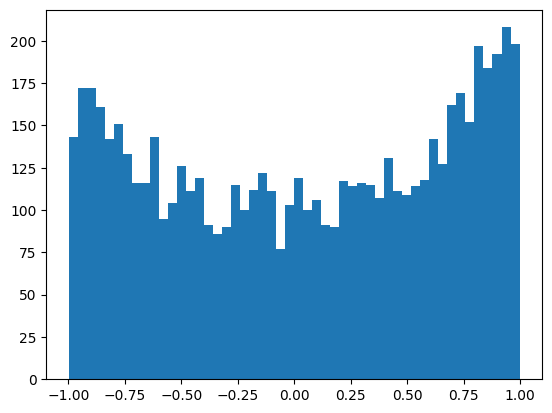

In [52]:
plt.hist((h.view(-1).tolist()), 50);

# we can see that most of the values are taking 1 and -1 here that tells us that our tanh is very active

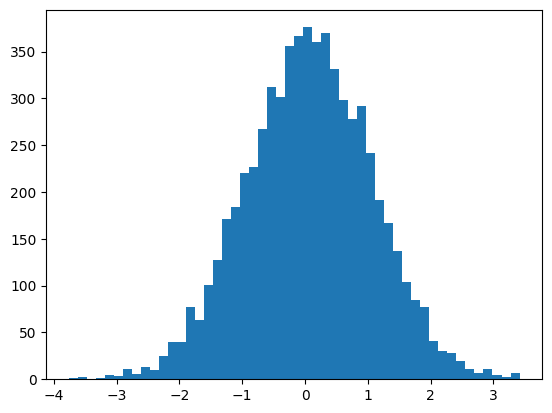

In [53]:
plt.hist((hpreact.view(-1).tolist()), 50);

# preactivation is pretty broad and taking a lot of values

So, what does this mean?\
if we check the backpropagation algorithm for tanh, derivative for a tanh neuron is (1 - t**2)
```
def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad # local derivative * global derivative
        out._backward = _backward
        return out
```
Basically, self.grad is becoming zero whenever x is 1 or -1. So, we are facing a problem of vanishing gradients here as most of the tanh values are 1 and -1\
And when t = 0, we are getting self.grad as out.grad. So, basically tanh neuron become inactive essentially and not changing the gradient at all

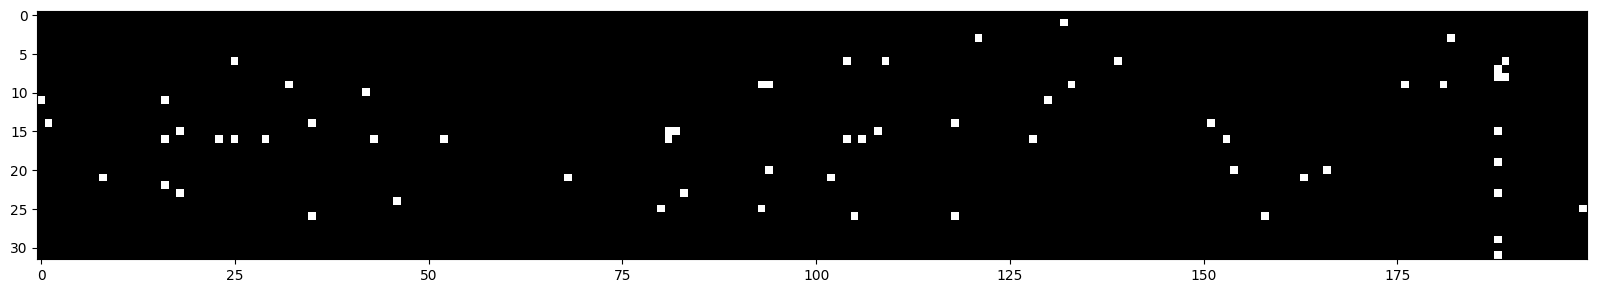

In [54]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # checking for the flat part or the extreme part of the tanh where the gradients are getting destroyed

there are 200 neurons in the tanh or hidden layer and there 32 examples.\
White part represents the h.abs() > 0.99 is true and black represents false\
We want to see if there is a dead neuron. For that we will check a complete column of whites but we cannot find any here\
Dead neuron is the when the neuron is not active even for one example so essentially it does not provide any value in the network.

Now what do we want to do after this?\
We want hpreact values to be near zero. From the plot above of hpreact, we can see that they are spread out. We don't want that\
To make hpreact near zero, we can initialize W1 and b1 as very small values\
After making the W1 and b1, we should see much less values of white in the imshow() => it is almost black that tells us that all the neurons got activated

When we are setting up scale numbers during the initialization, how do we come up with those numbers?

In [ ]:
# Example to demonstrate scaling the parameters
x = torch.randn(1000, 10)  # 1000 inputs each with a dimension of 10
w = torch.randn(10, 200) / 10 ** 0.5 # 200 neurons with 10 input size
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

# what we can see is that mean is same for both x and y i.e. both inputs and outputs but standard deviation expanded. Output became more spread out.
# mean is same is it is a symmetrical operation
# we don't want to change the standard deviation throughout the neural network and we want the keep the activations roughly the same.
# why?
# because irregular distribution makes the gradients too big or too small
# now if I multiply w with a big number like 20, the gaussian becomes more and more unstable as SD expands more
# and if I multiply w with a very small number like 0.2, gaussian becomes stable.
# now the question is what is the scaling factor?
# a thumb rule to scale the weights for any neural network is to divide it by the square root of number of inputs in that layer. This is also called fan_in
# so in above example, we will divide it by sqrt(10)
# Kaiming init => read pytorch documentation for this
# but for tanh, it is (5/3) / (sqrt(fan_in))
# so just multiply by the Kaiming init number

# although these initializations are not that important with the current architectures and the new innovations like batch normalization

tensor(-0.0045) tensor(1.0002)
tensor(-0.0043) tensor(3.1153)


# Batch normalization
why do we need batch normalization?\
From the examples above, we want our hidden layers values to be nearly Gaussian (normal distribution).\
The reason for this was that the extreme values in the preactivation layer are squashed to 1 or -1 which in turn becomes zero while calculating gradient of tanh during backprop and very small values (almost zero) makes the tanh inactive.\
Because of this we want the preactivation values to be roughly Gaussian.\
So, what batch normalization does it that it actually converts hidden layer values into Gaussian distribution.\
Now, how do we convert a distribution to a Gaussian distribution?\
xi = (xi - mean)/std

In [6]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
W1 = torch.randn((block_size * n_embd, 200),    generator=g) * (5/3)/((block_size * n_embd) ** 0.5)  #  <=this is Kaiming init #* 0.2
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0 # initialization to make logits zero

bngain = torch.ones((1, n_hidden))  # batch normalization gain
bnbias = torch.zeros((1, n_hidden)) # batch normalization bias

bnmean_running = torch.zeros((1, n_hidden)) # setting this to 0s as during the initialization, bnbias is zero and bngain is 1, so basically running mean would be roughly 0 and std be roughly 1
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

In [80]:
# to makse sense of the broadcasting happening because of bngain and bnbias
print(hpreact.shape)
print(hpreact.mean(0, keepdim=True).shape)  # we want mean and std across the batch
print(hpreact.std(0, keepdim=True).shape)
print(((hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)).shape)
(bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)).shape

torch.Size([32, 200])
torch.Size([1, 200])
torch.Size([1, 200])
torch.Size([32, 200])


torch.Size([32, 200])

In [97]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the two vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre activation
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    
    with torch.no_grad():  # we don't need to find gradients for these variables as we are not using them for optimizing the network
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani  # sort of nudging it in the direction of the mean/std of the batch
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weight updates
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


Now, we did convert the preactivation values into the Gaussian distribution. But we kind of want that just during the initialization. As we want the backprop algorithm to set the tone of the distribution later. The distribution might shrink or might shift and we don't want to stop that by forcing the values to Gaussian distribution.\
In the batch normalization paper, to deal with this we are multiplying by gain and adding an offset.\
We will add them as the parameters of the neural network so that they also get trained.\
Basically, xi = bngain * ((xi - mean)/std) + bnbias

It is customary to take a linear layer or convolution layer and append a batch normalization layer to it to control the scale of activation at every point of neural network

In [ ]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

bnmean.shape, bnstd.shape

# since the during the inference time, we are just inputting one example to get a sensible result from that but the neural network expects a batch. So, after the training we calculate
# the mean and standard deviation and then use them during the inference time.
# But in the production and in pytorch what happens is that the network calculates these running mean and running std during the training time

(torch.Size([1, 200]), torch.Size([1, 200]))

In [98]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    # hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias  # calculated the running mean and running std during the training process
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 2.06659197807312
val 2.1050572395324707


In [ ]:
b1.grad
# we can see that b1's gradient are almost all zero. This is because they are getting subtracted out here hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
# this does not contribute anything to network so we can might as well remove it from the network for efficiency reasons.

tensor([ 4.6566e-10, -1.8626e-09,  8.7311e-10, -6.9849e-10, -4.6566e-10,
         1.8626e-09, -2.3283e-10, -2.3283e-09,  4.6566e-10, -2.7940e-09,
         1.3970e-09, -3.7253e-09,  1.8626e-09,  0.0000e+00,  4.6566e-10,
        -4.6566e-10,  6.9849e-10, -9.3132e-10, -1.1642e-09, -9.3132e-10,
        -1.1642e-09, -4.6566e-10,  2.9104e-11, -9.3132e-10, -1.1642e-09,
         4.6566e-10, -2.0955e-09,  0.0000e+00,  0.0000e+00, -3.4925e-10,
        -9.3132e-10, -3.0268e-09, -6.9849e-10,  1.5134e-09,  0.0000e+00,
        -1.3970e-09,  4.6566e-10,  1.8626e-09,  4.6566e-10, -1.8626e-09,
        -9.3132e-10,  5.8208e-10, -1.8626e-09, -2.3283e-10,  1.3970e-09,
         8.7311e-10, -9.8953e-10,  2.3283e-09,  9.3132e-10,  2.5611e-09,
         3.7253e-09,  9.3132e-10,  0.0000e+00,  2.3283e-09,  0.0000e+00,
        -4.6566e-10,  0.0000e+00, -2.3283e-10, -4.6566e-10, -4.6566e-10,
         4.6566e-10,  4.6566e-10,  2.3283e-10, -9.3132e-10,  4.6566e-10,
        -9.3132e-10,  1.3970e-09,  2.7940e-09,  0.0

In [ ]:
# after fixing the softmax
# train 2.0695888996124268
# val 2.131074905395508

# after fixing tanh saturation at init
# train 2.0355966091156006
# val 2.1026782989501953

# after adding a batch normalization layer
# train 2.0668270587921143
# val 2.104844808578491

Now, a very weird thing is happening in the batch normalization.\
Initially, we started off with one example, calculated the preactivations and logits of that example and then eventually loss.\
After that the batch or the mini-batch concept came. Essentially just for the efficiency purpose this was used.\
Now in batch normalization, for one example, logits or hpreact is a function of all the other examples in that batch due to mean and std.\
One would think that this is a bug, but as it turns out, it is not. Actually this works pretty well for the batch normalization.\
The reason why this thing makes sense is because when we are finding h and logits for one example, that value will jitter or fluctuate from batch to batch.\
That in turn will make the value of logits jitter. This jitter effect means that the numerical value of a particular example is not just the function of that particular example but also a function of the statistical composition of the batch it is in.\
This jittering effect actually works as a regularizer which inturn helps neural network so that it doesn't overfit.

Just to summarize batch normalization; Batch normalization is used to make the distribution of activations of any layer roughly the same as the distribution of the input.\
We introduced two new trainable parameter; one gain and one bias. These are added to make the neural network be too much restricted on the Gaussian plane.\
We want to learn the behavior of the input better and we want distribution to expand and move as per the input space. That is why we introduced them.\
Typically, we take the linear layer, add batch normalization, and then apply non linearity.\
Example: linear layer -> Batch normalization layer -> Relu or tanh (whatever basically)

In [159]:
# Now we will arrange the code in a more "pytorchy" way

class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) #/ fan_in**0.5 # this initialization not much needed in case of BN, the network would behave relatively good
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    
        def __init__(self, dim, eps=1e-5, momentum=0.1):
            # hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
            self.eps = eps
            self.momentum = momentum
            self.training = True
            # affine parameters (trained with backprop)
            self.gamma = torch.ones(dim)
            self.beta = torch.zeros(dim)
            # buffers (trained with running 'momentum update')
            self.running_mean = torch.zeros(dim)
            self.running_var = torch.ones(dim)
        
        
        def __call__(self, x):
            if self.training:
                xmean = x.mean(0, keepdim=True)
                xvar = x.var(0, keepdim=True)
            else:
                xmean = self.running_mean
                xvar = self.running_var
            
            xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
            self.out = self.gamma * xhat + self.beta
            
            # update the buffers
            if self.training:
                with torch.no_grad():
                    self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                    self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
            return self.out

        def parameters(self):
            return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out 

    def parameters(self):
        return []

In [160]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # making last layer less confident
    # layers[-1].weight *= 0.1  # To make the logits smaller and inturn making probabilities uniform
    layers[-1].gamma *= 0.1 # we will not change the weights in case of BN, but we will change the gamma as gamma is responsible to make the probabilities less confident now
    # apply gain to all the other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *=  1#5/3#0.5#5/3#3 #0.5 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47551


In [161]:
# traning script
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio

for i in range(max_steps):
    
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    
    # forward pass and loss calculation
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # weights update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item()  for p in parameters])
        
    
    if i >= 1000:
        break

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.63, saturated: 2.59%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.34%
layer 11 (      Tanh): mean -0.00, std 0.64, saturated: 2.62%
layer 14 (      Tanh): mean +0.00, std 0.64, saturated: 2.50%


Text(0.5, 1.0, 'activation distribution')

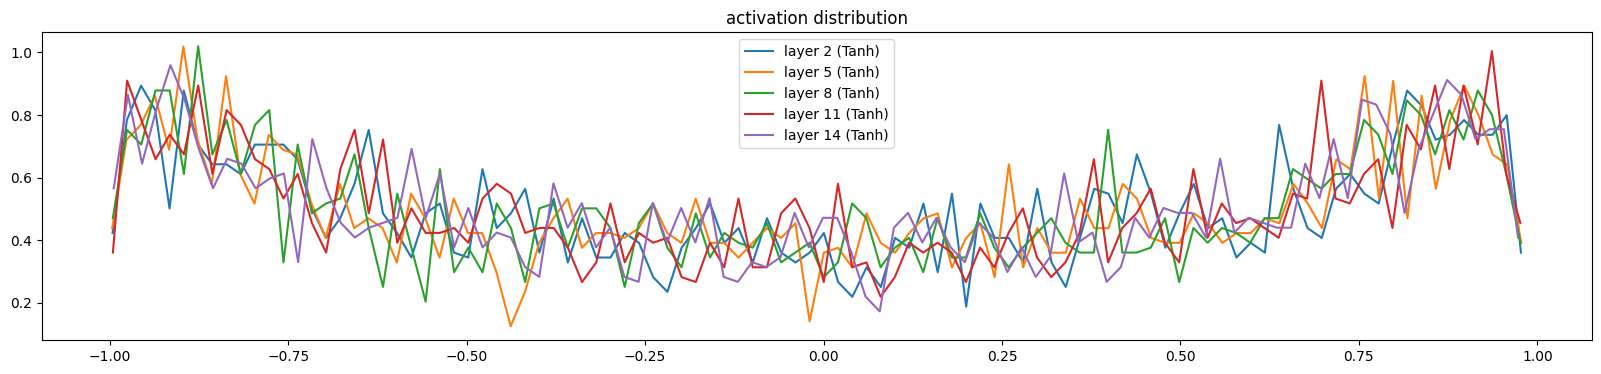

In [162]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    # print(t.shape)  # just for debugging
    # print((t.abs() > 0.97).float().mean()) # every element of t get compares with 0.97, and aggregate mean is taken 
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

In [163]:
# when weight gain is 1 in linear layers
# layer 1 (      Tanh): mean -0.02, std 0.62, saturated: 3.50%
# layer 3 (      Tanh): mean -0.00, std 0.48, saturated: 0.03%
# layer 5 (      Tanh): mean +0.00, std 0.41, saturated: 0.06%
# layer 7 (      Tanh): mean +0.00, std 0.35, saturated: 0.00%
# layer 9 (      Tanh): mean -0.02, std 0.32, saturated: 0.00%

# so when weight gain is not applied (basically 1), we can see that std is decreasing. That means with every layer, distribution is shrinking to zero. Why?
# because we have already multiplied weights with 1/sqrt(fan_in) that is making the distribution somewhat normal (roughly the same is input distribution).
# After that tanh layer is there, which is inturn squashing the distribution. To fight the squashing, we need to give it a gain.   

# when weight gain is 5/3 in linear layers
# layer 1 (      Tanh): mean -0.02, std 0.75, saturated: 20.25%
# layer 3 (      Tanh): mean -0.00, std 0.69, saturated: 8.38%
# layer 5 (      Tanh): mean +0.00, std 0.67, saturated: 6.62%
# layer 7 (      Tanh): mean -0.01, std 0.66, saturated: 5.47%
# layer 9 (      Tanh): mean -0.02, std 0.66, saturated: 6.12%

# 5/3 is the perfect gain when tanh in involved. By the third layer, std is stabilized and we have decent amount of saturation.

# when weight gain is 3 in linear layers
# layer 1 (      Tanh): mean -0.03, std 0.85, saturated: 47.66%
# layer 3 (      Tanh): mean +0.00, std 0.84, saturated: 40.47%
# layer 5 (      Tanh): mean -0.01, std 0.84, saturated: 42.38%
# layer 7 (      Tanh): mean -0.01, std 0.84, saturated: 42.00%
# layer 9 (      Tanh): mean -0.03, std 0.84, saturated: 42.41%

# When gain is very high, we see that std is stabilized very quickly but saturation is very high


layer 2 (      Tanh): mean +0.000000, std 3.093912e-03
layer 5 (      Tanh): mean +0.000000, std 2.661322e-03
layer 8 (      Tanh): mean +0.000000, std 2.426213e-03
layer 11 (      Tanh): mean -0.000000, std 2.269459e-03
layer 14 (      Tanh): mean -0.000000, std 1.983031e-03


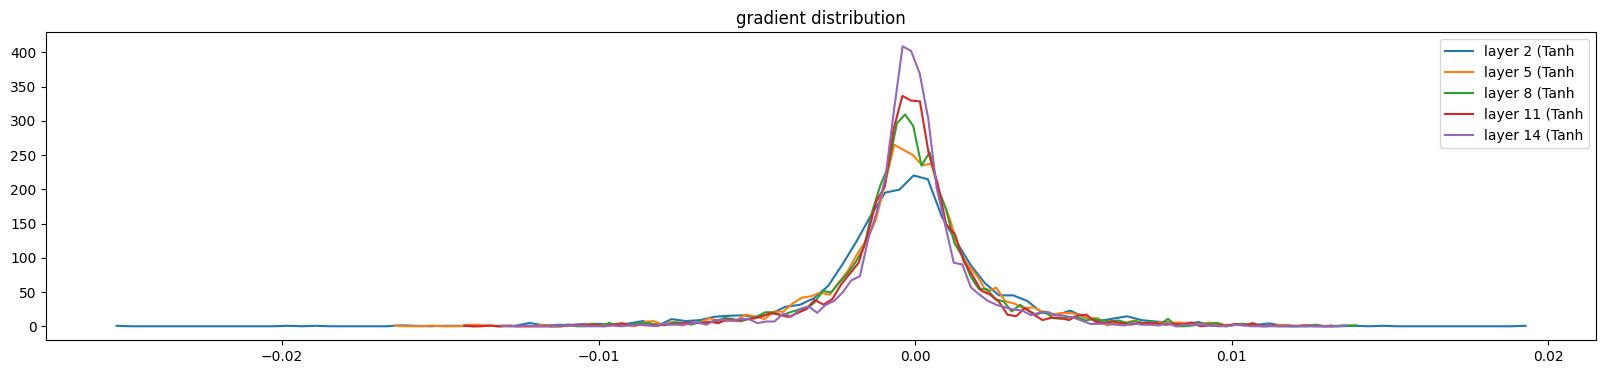

In [164]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution');

# we want to check that gradients of different layers are roughly the same.

In [165]:
# when gain is 0.5, the gradients are spreading out. That should be the case as when the gain is low, the activations will be shrinking to 0 as tanh is squashing it after the activations
# and before the next linear layer.
# and with the subsequent layers, tanh will be roughly zero all the time since preactivation is approacing zero

In [166]:
# if we remove the tanh layers from our network, what would happen?
# we have already multiplied the weights with 1 / sqrt(fan_in)
# now if gain is 5/3 (ideal gain for linear layers is just 1). Basically, we are boosting the value as compared to the ideal scenario.
# after each layer, activations will increase (as weights are amplified and there is no squashing function). Hence, the distribution after each passing layer becomes more diffused.

# and if the gain is very small (say 0.5), the opposite will happen. With each layer, the activations will be tending to zero.


A very interesting concept or an idea about neural networks. Why do we need tanh or any other non linear function?\
The answer to the question is not that complicated. Basically we need some kind of non linearity to approximate any arbitrary function.\
A stack of linear layers is just a linear function at the end of the day. There is a limit how complicated that function can be.\
Now, the interesting part. Suppose, we have a neural network with multiple linear layers (no non linear layers).\
So, in the forward pass of the network, no matter how big the network is, all layers can be replaced by one different W weight layer that exactly represents the forward pass of this network.\
But, the interesting part is that backward propagation is completely different as relationships between output and intermediate layers are totally different.\
So, we get a different backpropagation optimization pass.

weight   (27, 10) | mean +0.000000 | std 6.705948e-03 | grad:data ratio 6.700179e-03
weight  (30, 100) | mean -0.000003 | std 2.026517e-03 | grad:data ratio 1.977298e-03
weight (100, 100) | mean +0.000013 | std 1.104427e-03 | grad:data ratio 1.108056e-03
weight (100, 100) | mean +0.000005 | std 9.566543e-04 | grad:data ratio 9.497148e-04
weight (100, 100) | mean +0.000003 | std 8.406345e-04 | grad:data ratio 8.380438e-04
weight (100, 100) | mean +0.000001 | std 7.872587e-04 | grad:data ratio 7.840730e-04
weight  (100, 27) | mean -0.000002 | std 1.212762e-03 | grad:data ratio 1.226612e-03


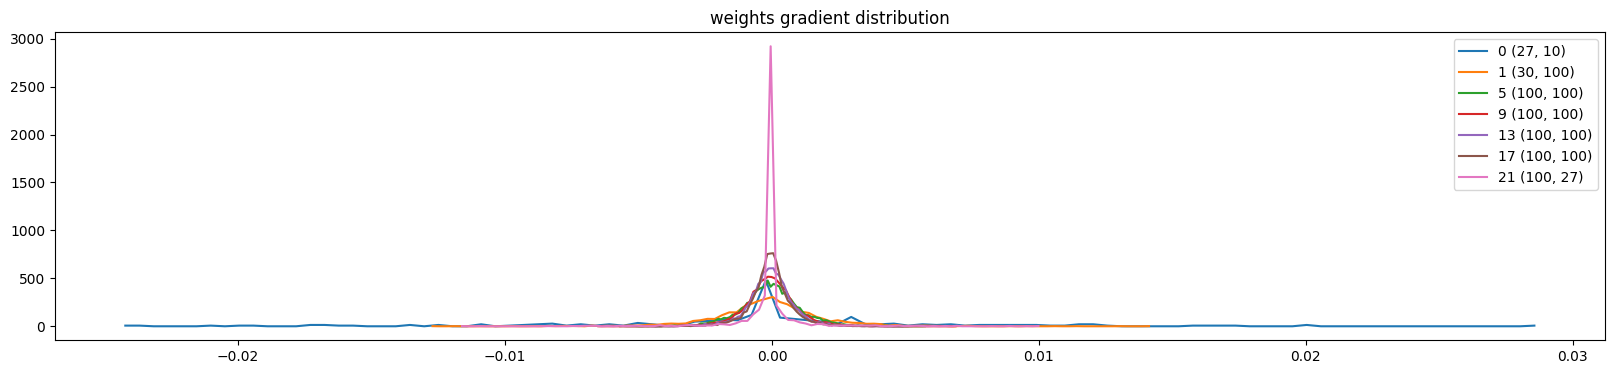

In [167]:
# though proces behind this plot. We are ultimately changing parameters. We care about parameters values and their gradients
# we are calculating gradient to data ratio to know by what factor are we changing the parameters. (scale of gradient to the scale of values)

plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad 
  if p.ndim == 2: # just restricting to dims=2 i.e just weights for simplicity
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');


# weight   (27, 10) | mean -0.000031 | std 1.365078e-03 | grad:data ratio 1.364090e-03
# weight  (30, 100) | mean -0.000049 | std 1.207430e-03 | grad:data ratio 3.871660e-03
# weight (100, 100) | mean +0.000016 | std 1.096730e-03 | grad:data ratio 6.601988e-03
# weight (100, 100) | mean -0.000010 | std 9.893572e-04 | grad:data ratio 5.893091e-03
# weight (100, 100) | mean -0.000011 | std 8.623432e-04 | grad:data ratio 5.158124e-03
# weight (100, 100) | mean -0.000004 | std 7.388577e-04 | grad:data ratio 4.415212e-03
# weight  (100, 27) | mean -0.000000 | std 2.364824e-02 | grad:data ratio 2.328203e+00

# we can see that for all the layers, gradient is roughly 1000 times smaller than the value that is perfectly fine.
# But in the last layer, that is not the case. Probably that is the trouble maker
# gradients in the last layer are taking much larger values as compared to the values inside.
# by checking standard deviation, we can see that gradient values are roughly 10 times greater than the values in the intermediate layer.
# so what that means in SGD, we will be training the last layer roughly 10 times faster than others (at initialization).
# this kind of fixes itself when the train the NN longer.

# after training the NN for 1000 steps, we see that gradients from output layers are shrinking.

In [168]:
# the above plot is informative but we can improve it.
# More than grad / data ratio, we should be more concerned about update / data ratio. 
# i.e. how big or small update is as compared to the data value

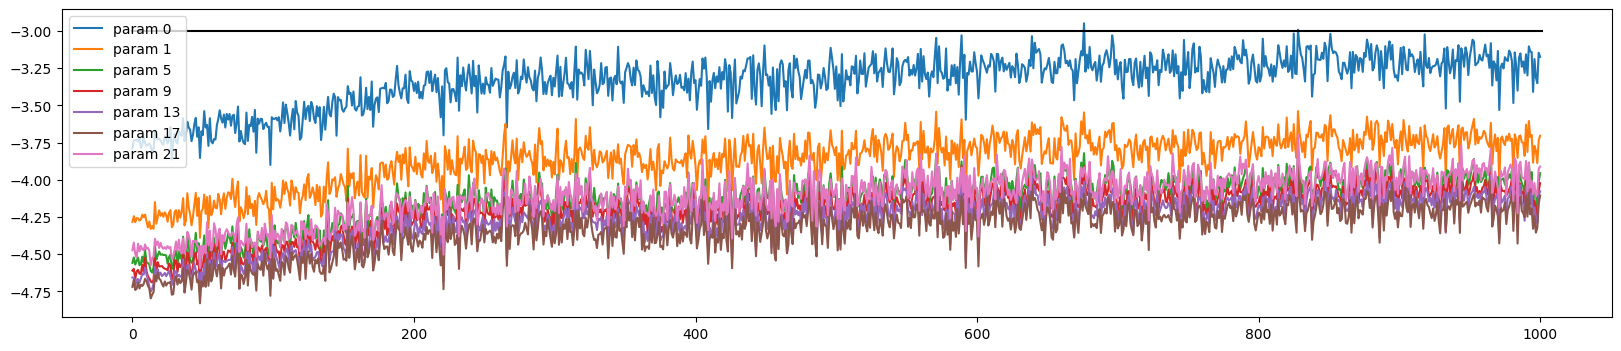

In [169]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot. This is a rough guide as to how much this ratio should be. Approx update should be around in the range of 10^-3 times to that of the magnitude of data
plt.legend(legends);


# from the plot we can see that the rate of change  of the last layer is high. That is because during the initialization, we made the last layer smaller intentionally to make the last
# layer less confident. Since, the values are small, so change will also be relatively bigger. After few iterations, the last layer change is also becoming stable.
# Roughly, we need to check if rates are not differing much to 1e-3 line.
# Because if it is lower than that, then training or updates are very slow.
# This is a good way to know what learning rate should be for the network. The current setup is decent and looks stable.
# from all these plots, it is fairly easy to point out if the network is miscalibrated.


# Even after the BN, the last plot can still come out to be not great. We might still be needed to change the initialization of the network but mostly, changing the learning rate
# would fix the problem.

Summary of this notebook:
1. We started off with the MLP network that we did last time.
2. We saw how initializing the network is very important (considering the fact that we are not using the latest tools like BN, Adam optimizer in the network)
3. We understood that the distribution of preactivations or activations should be roughly Gaussian so that we don't face the problem of vanishing gradients or no gradients.
4. We saw the repercussions of dialing down the weights of the hidden layer by a number on the distribution of that layer's activations and in turn the effect of that on optimization process.
5. There were some basic initialization like Kaiming initialization that stabilizes much of the training.
6. Then came the concept of batch normalization. Since, preactivations are supposed to be Gaussian, we took the distribution and made it a normal distribution using the mean and variance of that batch.
7. Generally, we keep the layers in the format of Linear Layer -> Batch Normalization layer -> Non Linearity like Tanh, Relu, Sigmoid, etc. We can also put the BN layer after the non linearity and we will get generally the same results but the format mentioned is generally practiced.
8. We learnt about different visualization diagnostic tools to calibrate our neural network efficiently.
9. We learnt how to check the plots of activations at different layers after the non linearity layer. The distributions for activations at each layers should roughly be the same.
10. Similar thing we check with the gradients at each layer. They should also be roughly equal and check the overall pattern of the plots.
11. Then we checked the grad / value ratio for the weight parameters in the network.
12. A better approach would be to check the update / value ratio for the weight parameters. Roughly, update / value ratio should be ~1e-3 for good optimization. If the ratio is less than this, than we need a faster training or update and if it is significantly higher than this, than we need to slow down the updates.
